# Sparse Classification of Disease Phase (Diagnosis vs. Relapse)

### PPTC 2019 Clinical Dataset — Pediatric Cancer

**Goal:** The goal of this project is to used the LASSO-penalized logistic regression (sparse classification) technique to identify the *minimal* genomic feature subset that predicts whether a pediatric cancer sample is at **Diagnosis** or **Relapse**.

**Problem Statement:** We would solve for a sparse coefficient vector **β** via L1 regularization, mimicking the SINDy philosophy — identify the fewest, most informative features that govern the system's state.

**Pipeline:**
1. Data loading & preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Sparse Logistic Regression (LASSO)
5. Elastic Net comparison
6. Feature selection analysis (which features survive regularization)
7. Model evaluation & interpretation
8. Regularization path visualization

---
# 1. Importing Data & Setup

### Importing the Packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

### Defining the Seeds and Plot Style

In [3]:
SEED = 42
np.random.seed(SEED)

plt.rcParams.update({'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,})

PALETTE = {'Diagnosis': '#2196F3', 'Relapse': '#E53935'}

print('Imports successful.')

Imports successful.


---
### Data Loading & Preprocessing

* Load the pptc_2019_clinical_data

In [4]:
df_raw = pd.read_csv('pptc_2019_clinical_data.tsv', sep='\t')
print(f'Raw dataset: {df_raw.shape[0]} samples × {df_raw.shape[1]} columns')

# Show the first three entries of the data
df_raw.head(3)

Raw dataset: 261 samples × 21 columns


,studyId,patientId,sampleId,CANCER_SUBTYPE_CURATED,CANCER_TYPE,CANCER_TYPE_DETAILED,EXPRESSION,FRACTION_GENOME_ALTERED,HISTOPATHOLOGY,MUTATION_COUNT,...,ONCOTREE_CODE,PHASE,SAMPLE_SITE,SITE_OF_SPECIMEN,TMB_NONSYNONYMOUS,AGE,INFERRED_ETHNICITY,REPORTED_ETHNICITY,SAMPLE_COUNT,SEX
0,pptc_2019,P0111,IC-6634GBM,Glioblastoma,Glioma,Glioblastoma,NO,0.2154,"GFAP+, PTEN+",25.0,...,GB,Diagnosis,Cerebrum,Cerebrum,0.833333,17.00,European,Hispanic or Latino,1,Male
1,pptc_2019,P0201,OS-34-SJ,Osteosarcoma,Bone Cancer,Osteosarcoma,NO,0.3360,Not noted,118.0,...,OS,Diagnosis,L. Femur,L. Femur,3.933333,14.00,European,Unknown,2,Female
2,pptc_2019,P0194,OS-17,Osteosarcoma,Bone Cancer,Osteosarcoma,NO,0.2514,Not noted,123.0,...,OS,Diagnosis,Unknown,Femur,4.100000,16.42,European,European,1,Male


In [5]:
df = df_raw[df_raw['PHASE'].isin(['Diagnosis', 'Relapse'])].copy()

### Assign binary values to the value Phase    

* 0=Diagnosis, 1=Relapse


In [6]:
df['PHASE_BINARY'] = (df['PHASE'] == 'Relapse').astype(int)  

print(f'Binary dataset: {df.shape[0]} samples')
print(df['PHASE'].value_counts().to_string())

Binary dataset: 234 samples
PHASE
Diagnosis    164
Relapse       70


# 2. Feature Engineering

In [7]:
# Numeric features (core genomic + clinical)
NUMERIC_FEATURES = ['AGE', 'MUTATION_COUNT', 'TMB_NONSYNONYMOUS', 'FRACTION_GENOME_ALTERED']

# Categorical: one-hot encode CANCER_TYPE (drop rare classes with < 3 samples to avoid noise)
cancer_counts = df['CANCER_TYPE'].value_counts()
common_cancers = cancer_counts[cancer_counts >= 3].index.tolist()
df['CANCER_TYPE_FILTERED'] = df['CANCER_TYPE'].where(df['CANCER_TYPE'].isin(common_cancers), other='Other')

cancer_dummies = pd.get_dummies(df['CANCER_TYPE_FILTERED'], prefix='CT', drop_first=False)
sex_dummies    = pd.get_dummies(df['SEX'], prefix='SEX', drop_first=True)  # Male=1, Female=0

In [8]:
# Assemble feature matrix

X = pd.concat([
    df[NUMERIC_FEATURES].reset_index(drop=True),
    cancer_dummies.reset_index(drop=True),
    sex_dummies.reset_index(drop=True),
], axis=1)

y = df['PHASE_BINARY'].reset_index(drop=True)

print(f'Feature matrix shape: {X.shape}')
print(f'Features: {list(X.columns)}')

Feature matrix shape: (234, 15)
Features: ['AGE', 'MUTATION_COUNT', 'TMB_NONSYNONYMOUS', 'FRACTION_GENOME_ALTERED', 'CT_B-Lymphoblastic Leukemia/Lymphoma', 'CT_Bone Cancer', 'CT_Embryonal Tumor', 'CT_Glioma', 'CT_Leukemia', 'CT_Other', 'CT_Peripheral Nervous System', 'CT_Soft Tissue Sarcoma', 'CT_T-Lymphoblastic Leukemia/Lymphoma', 'CT_Wilms Tumor', 'SEX_Male']


### Addressing the Missing Values

In [9]:
missing = X.isnull().sum()
print('Missing values per feature:')
print(missing[missing > 0].to_string())
print(f'\nTotal: {missing.sum()} missing values across {(missing > 0).sum()} features')

# Impute: median for numerics (robust to outliers), 0 for dummies (already complete)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
) 
print('\nAfter imputation - number of missing values:', X_imputed.isnull().sum().sum())

Missing values per feature:
AGE                        17
MUTATION_COUNT             19
FRACTION_GENOME_ALTERED     9

Total: 45 missing values across 3 features

After imputation - number of missing values: 0


---
# 3. Exploratory Data Analysis

* Print out the count bar graph for "Diagnosis" and "Relapse" phase.
* Print out the Counts breakdown("Diagnosis" or "Relapse") for each cancer types.

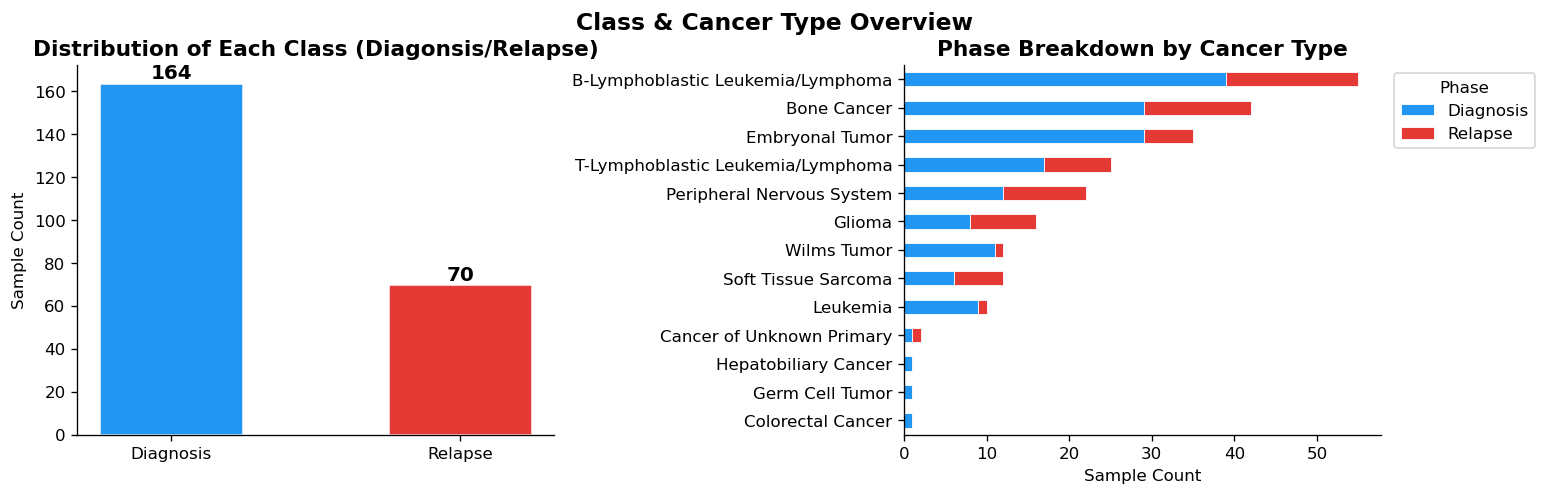

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar: class counts
counts = df['PHASE'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[PALETTE[p] for p in counts.index], edgecolor='white', linewidth=1.5, width=0.5)
for i, (phase, n) in enumerate(counts.items()):
    axes[0].text(i, n + 2, str(n), ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Each Class (Diagonsis/Relapse)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sample Count')
axes[0].set_xlabel('')

# Stacked bar: phase by cancer type
ct_phase = df.groupby(['CANCER_TYPE', 'PHASE']).size().unstack(fill_value=0)
ct_phase = ct_phase.loc[ct_phase.sum(axis=1).sort_values(ascending=True).index]
ct_phase[['Diagnosis','Relapse']].plot(
    kind='barh', stacked=True, ax=axes[1],
    color=[PALETTE['Diagnosis'], PALETTE['Relapse']],
    edgecolor='white', linewidth=0.5)


axes[1].set_title('Phase Breakdown by Cancer Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sample Count')
axes[1].set_ylabel('')
axes[1].legend(title='Phase', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.suptitle('Class & Cancer Type Overview', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### Genomic feature distributions by phase

* Print out the Distribution of Phase (Diagnosis/Relapse) for each Genomic & Clinical Features.

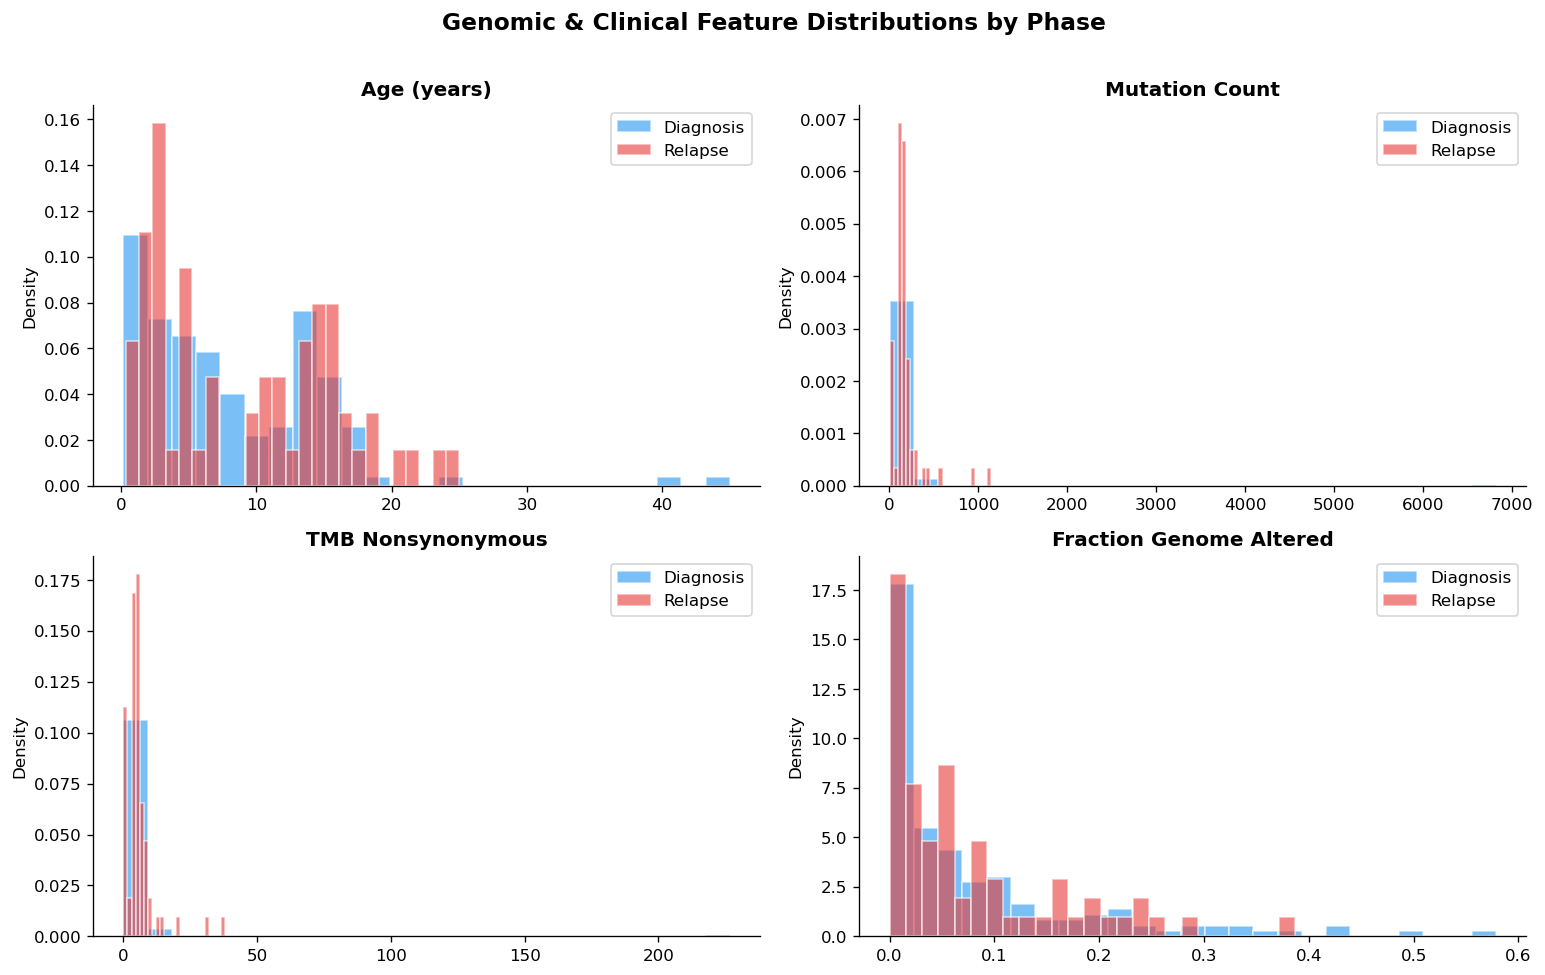

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

feat_labels = {
    'AGE': 'Age (years)',
    'MUTATION_COUNT': 'Mutation Count',
    'TMB_NONSYNONYMOUS': 'TMB Nonsynonymous',
    'FRACTION_GENOME_ALTERED': 'Fraction Genome Altered'}

for ax, (feat, label) in zip(axes, feat_labels.items()):
    for phase, color in PALETTE.items():
        subset = df[df['PHASE'] == phase][feat].dropna()
        ax.hist(subset, bins=25, alpha=0.6, color=color, label=phase, density=True, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Genomic & Clinical Feature Distributions by Phase', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Correlation heatmap of numeric features
* Print the correlation heatmap of numeric features 

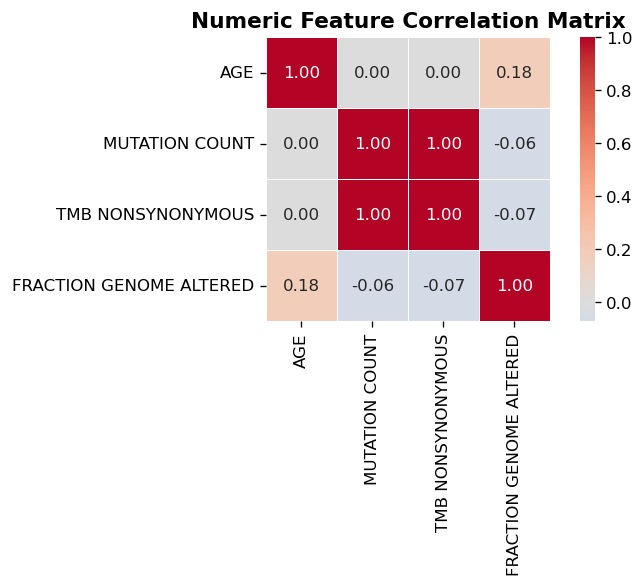

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = X_imputed[NUMERIC_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.5, ax=ax, square=True,
    xticklabels=[f.replace('_',' ') for f in NUMERIC_FEATURES],
    yticklabels=[f.replace('_',' ') for f in NUMERIC_FEATURES]
)
ax.set_title('Numeric Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 4. Sparse Logistic Regression (LASSO — L1)

We would use Lasso - L1-penalized logistic regression to help us identify a sparest subsets of important features that explains the data.


The L1-penalized logistic regression will solves:

$$\hat{\beta} = \arg\min_{\beta} \left[ -\ell(\beta; X, y) + \frac{1}{C} \|\beta\|_1 \right]$$

where $\ell$ is the log-likelihood and $C$ is the inverse regularization strength. **Small $C$ → stronger sparsity → fewer features survive.**


In [13]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
feature_names = list(X_imputed.columns)

print('Feature matrix after scaling:')
print(f'  Shape : {X_scaled.shape}')
print(f'  Mean  : {X_scaled.mean(axis=0).mean():.4f}  (should be ~0)')
print(f'  Std   : {X_scaled.std(axis=0).mean():.4f}  (should be ~1)')

Feature matrix after scaling:
  Shape : (234, 15)
  Mean  : -0.0000  (should be ~0)
  Std   : 1.0000  (should be ~1)


In [14]:
#  Cross-validated LASSO: find optimal C

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


# This code below would run a loop and search over 50 C values from 0.001 to 100

lasso_cv = LogisticRegressionCV(
    Cs=np.logspace(-3, 2, 50),
    cv=cv,
    penalty='l1',
    solver='saga',
    scoring='roc_auc',
    max_iter=5000,
    random_state=SEED,
    n_jobs=-1
)
lasso_cv.fit(X_scaled, y)

best_C_lasso = lasso_cv.C_[0]
print(f'Optimal C (LASSO):  {best_C_lasso:.5f}')
print(f'Equivalent lambda:  {1/best_C_lasso:.5f}  (= 1/C)')

Optimal C (LASSO):  79.06043
Equivalent lambda:  0.01265  (= 1/C)


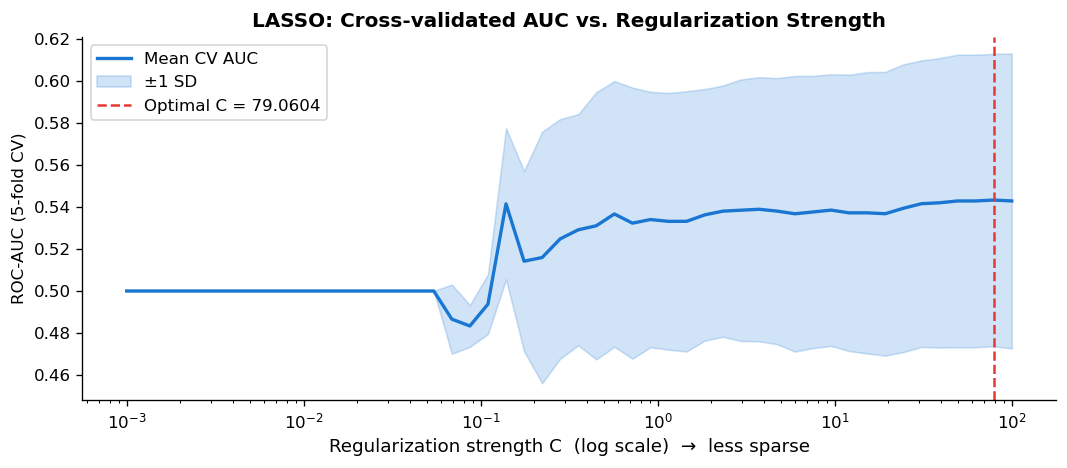

In [15]:
#  Plot CV score vs C

Cs = lasso_cv.Cs_
# class 1 = Relapse

scores_mean = lasso_cv.scores_[1].mean(axis=0)  
scores_std  = lasso_cv.scores_[1].std(axis=0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(Cs, scores_mean, color='#1976D2', lw=2, label='Mean CV AUC')
ax.fill_between(Cs, scores_mean - scores_std, scores_mean + scores_std,
                alpha=0.2, color='#1976D2', label='±1 SD')
ax.axvline(best_C_lasso, color='#E53935', lw=1.5, ls='--', label=f'Optimal C = {best_C_lasso:.4f}')
ax.set_xlabel('Regularization strength C  (log scale)  →  less sparse', fontsize=11)
ax.set_ylabel('ROC-AUC (5-fold CV)')
ax.set_title('LASSO: Cross-validated AUC vs. Regularization Strength', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Fit final LASSO model at optimal C 

lasso_model = LogisticRegression(
    C=best_C_lasso, penalty='l1', solver='saga',
    max_iter=5000, random_state=SEED
)
lasso_model.fit(X_scaled, y)

coef = lasso_model.coef_[0]
nonzero_mask = coef != 0
print(f'Total features          : {len(coef)}')
print(f'Non-zero (selected)     : {nonzero_mask.sum()}')
print(f'Zeroed out (eliminated) : {(~nonzero_mask).sum()}')
print(f'Sparsity                : {(~nonzero_mask).mean()*100:.1f}%')

Total features          : 15
Non-zero (selected)     : 15
Zeroed out (eliminated) : 0
Sparsity                : 0.0%


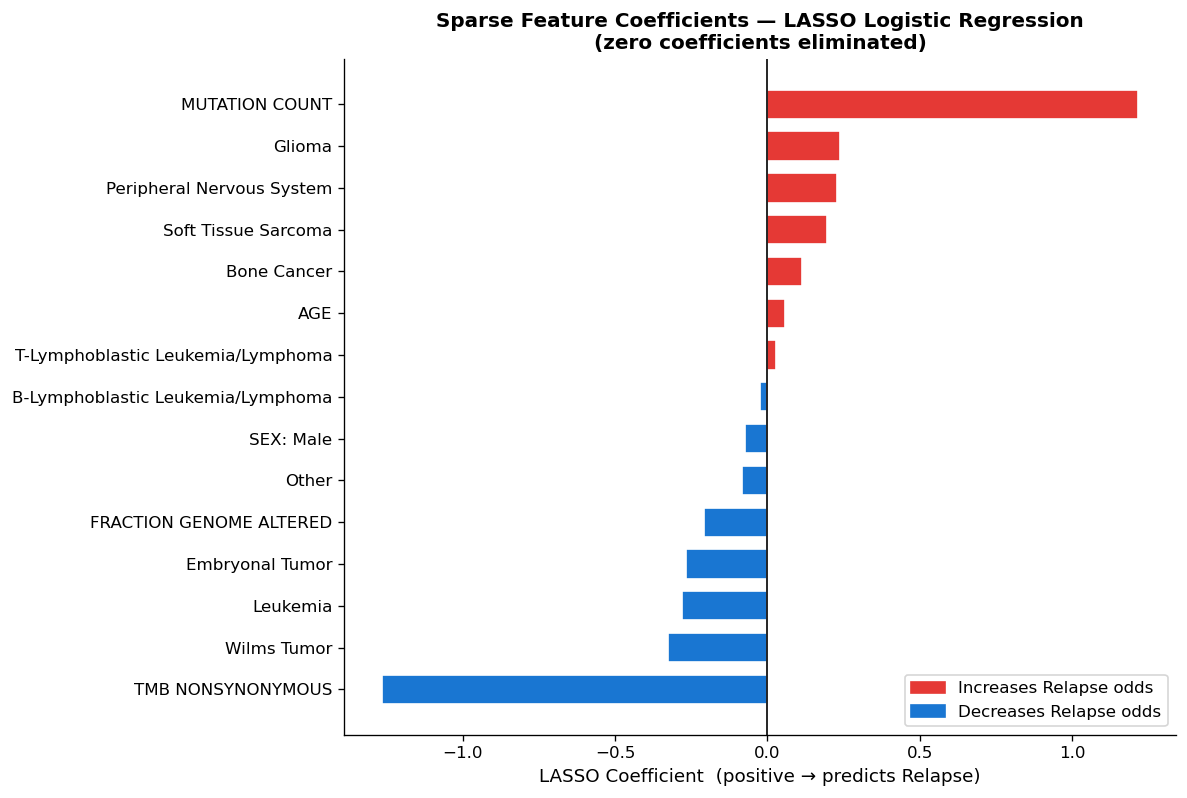

In [17]:
# Plot the Coefficients and their impacts on the Phase response variables

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coef})
coef_df = coef_df[coef_df['coefficient'] != 0].sort_values('coefficient')

colors = ['#E53935' if c > 0 else '#1976D2' for c in coef_df['coefficient']]

fig, ax = plt.subplots(figsize=(10, max(4, len(coef_df) * 0.45)))
bars = ax.barh(range(len(coef_df)), coef_df['coefficient'], color=colors, edgecolor='white', height=0.7)
ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels([f.replace('CT_','').replace('SEX_','SEX: ').replace('_',' ') for f in coef_df['feature']], fontsize=10)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('LASSO Coefficient  (positive → predicts Relapse)', fontsize=11)
ax.set_title('Sparse Feature Coefficients — LASSO Logistic Regression\n(zero coefficients eliminated)', fontweight='bold')

# Legend patches
from matplotlib.patches import Patch
legend_elements = [Patch(color='#E53935', label='Increases Relapse odds'),
                   Patch(color='#1976D2', label='Decreases Relapse odds')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

---
# 5. Elastic Net Comparison

Elastic Net balances L1 (sparsity) and L2 (stability) penalties:

$$\hat{\beta} = \arg\min_{\beta} \left[ -\ell(\beta; X, y) + \frac{1}{C} \left( \alpha \|\beta\|_1 + \frac{1-\alpha}{2} \|\beta\|_2^2 \right) \right]$$

We compare at `l1_ratio = 0.5` (balanced) and `l1_ratio = 0.9` (mostly sparse).

In [18]:
# Elastic Net models

results = {}

configs = {
    'LASSO (L1)':            dict(penalty='l1',           solver='saga', C=best_C_lasso),
    'Elastic Net (α=0.9)':   dict(penalty='elasticnet',   solver='saga', C=best_C_lasso, l1_ratio=0.9),
    'Elastic Net (α=0.5)':   dict(penalty='elasticnet',   solver='saga', C=best_C_lasso, l1_ratio=0.5),
    'Ridge (L2)':            dict(penalty='l2',           solver='lbfgs', C=best_C_lasso),
}

for name, kwargs in configs.items():
    model = LogisticRegression(max_iter=5000, random_state=SEED, **kwargs)
    auc_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='roc_auc')
    acc_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    model.fit(X_scaled, y)
    n_nonzero = (model.coef_[0] != 0).sum()
    results[name] = {
        'AUC mean': auc_scores.mean(),
        'AUC std':  auc_scores.std(),
        'Acc mean': acc_scores.mean(),
        'Acc std':  acc_scores.std(),
        'Non-zero features': n_nonzero,
        'model': model
    }

results_df = pd.DataFrame({
    k: {
        'CV ROC-AUC': f"{v['AUC mean']:.3f} ± {v['AUC std']:.3f}",
        'CV Accuracy': f"{v['Acc mean']:.3f} ± {v['Acc std']:.3f}",
        'Non-zero features': v['Non-zero features']
    } for k, v in results.items()
}).T

print('=== Model Comparison (5-fold CV) ===')
print(results_df.to_string())

=== Model Comparison (5-fold CV) ===
                        CV ROC-AUC    CV Accuracy Non-zero features
LASSO (L1)           0.544 ± 0.069  0.650 ± 0.021                15
Elastic Net (α=0.9)  0.544 ± 0.069  0.650 ± 0.021                15
Elastic Net (α=0.5)  0.545 ± 0.069  0.650 ± 0.021                15
Ridge (L2)           0.543 ± 0.070  0.650 ± 0.021                15


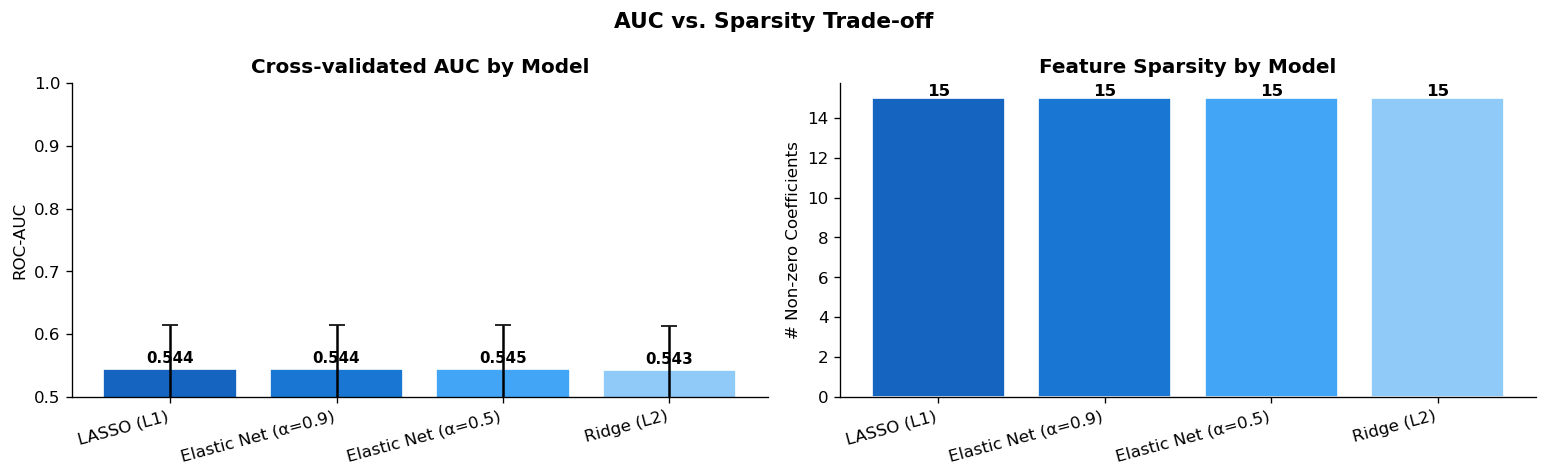

In [19]:
# Bar chart comparison
names  = list(results.keys())
aucs   = [results[n]['AUC mean'] for n in names]
aucs_e = [results[n]['AUC std']  for n in names]
nfeats = [results[n]['Non-zero features'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bar_colors = ['#1565C0', '#1976D2', '#42A5F5', '#90CAF9']
axes[0].bar(names, aucs, yerr=aucs_e, color=bar_colors, edgecolor='white', capsize=5)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('Cross-validated AUC by Model', fontweight='bold')
axes[0].set_xticklabels(names, rotation=15, ha='right')
for i, v in enumerate(aucs):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(names, nfeats, color=bar_colors, edgecolor='white')
axes[1].set_ylabel('# Non-zero Coefficients')
axes[1].set_title('Feature Sparsity by Model', fontweight='bold')
axes[1].set_xticklabels(names, rotation=15, ha='right')
for i, v in enumerate(nfeats):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('AUC vs. Sparsity Trade-off', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 6. Regularization Path

The **regularization path** shows how each coefficient evolves as we vary $C$ (sparsity). Features that enter first (at small $C$) are the most important predictors. This is directly analogous to the SINDy threshold sweep.

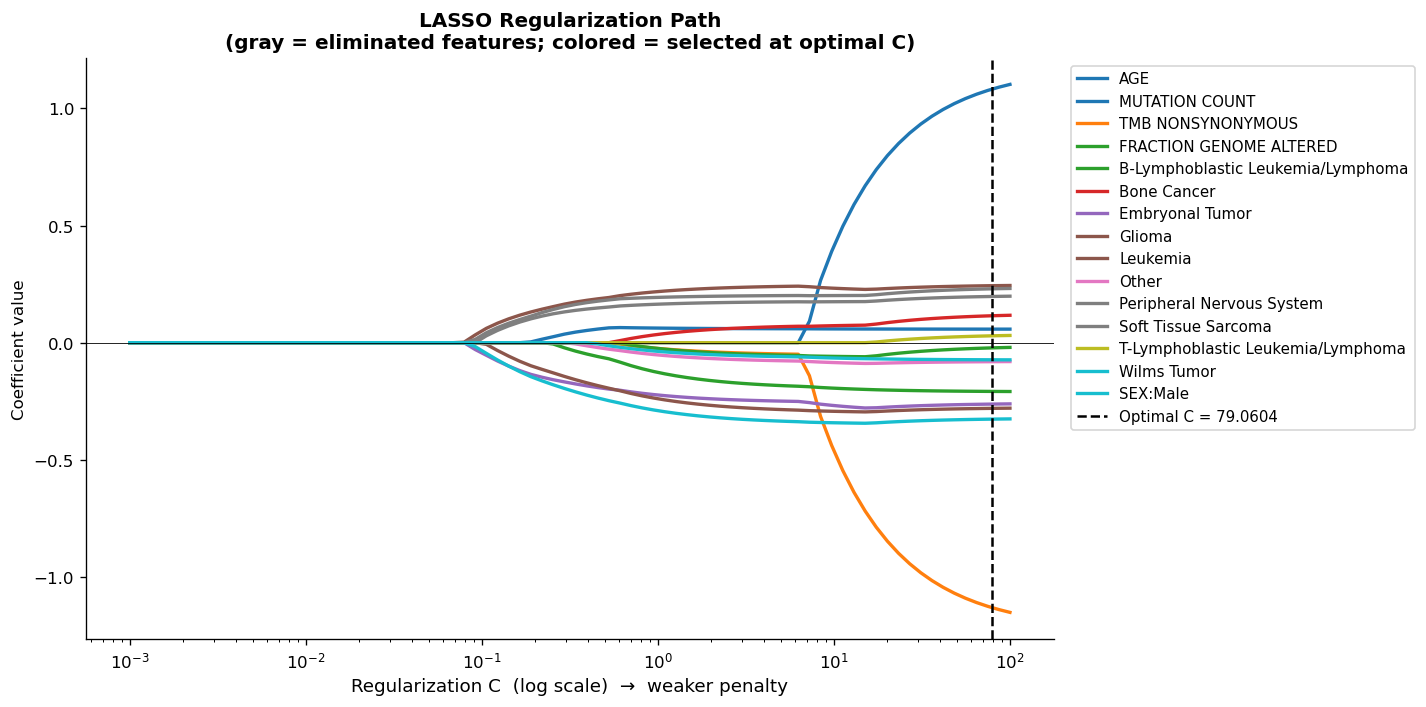

In [20]:
# Compute regularization path

C_path = np.logspace(-3, 2, 80)
coefs_path = []

for c in C_path:
    m = LogisticRegression(C=c, penalty='l1', solver='saga', max_iter=3000, random_state=SEED)
    m.fit(X_scaled, y)
    coefs_path.append(m.coef_[0])

coefs_path = np.array(coefs_path)  # shape: (n_C, n_features)

# Identify features that are non-zero at optimal C
opt_idx  = np.argmin(np.abs(C_path - best_C_lasso))
active   = np.where(coefs_path[opt_idx] != 0)[0]
inactive = np.where(coefs_path[opt_idx] == 0)[0]

fig, ax = plt.subplots(figsize=(12, 6))

# Plot inactive (zeroed at optimal C) in light gray
for i in inactive:
    ax.semilogx(C_path, coefs_path[:, i], color='lightgray', lw=0.8, alpha=0.5)

# Plot active features with color
cmap = plt.cm.get_cmap('tab10', len(active))
for j, i in enumerate(active):
    fname = feature_names[i].replace('CT_','').replace('SEX_','SEX:').replace('_',' ')
    ax.semilogx(C_path, coefs_path[:, i], lw=2, color=cmap(j), label=fname)

ax.axvline(best_C_lasso, color='black', lw=1.5, ls='--', label=f'Optimal C = {best_C_lasso:.4f}')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Regularization C  (log scale)  →  weaker penalty', fontsize=11)
ax.set_ylabel('Coefficient value')
ax.set_title('LASSO Regularization Path\n(gray = eliminated features; colored = selected at optimal C)', fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

---
# 7. Model Evaluation

In [21]:
# Full CV predictions for evaluation plots 

from sklearn.model_selection import cross_val_predict

y_pred_proba = cross_val_predict(
    lasso_model, X_scaled, y, cv=cv, method='predict_proba')[:, 1]

y_pred_class = (y_pred_proba >= 0.5).astype(int)

print('=== Classification Report (5-fold CV, threshold=0.5) ===')
print(classification_report(y, y_pred_class, target_names=['Diagnosis', 'Relapse']))

=== Classification Report (5-fold CV, threshold=0.5) ===
              precision    recall  f1-score   support

   Diagnosis       0.70      0.89      0.78       164
     Relapse       0.25      0.09      0.13        70

    accuracy                           0.65       234
   macro avg       0.47      0.49      0.45       234
weighted avg       0.56      0.65      0.59       234



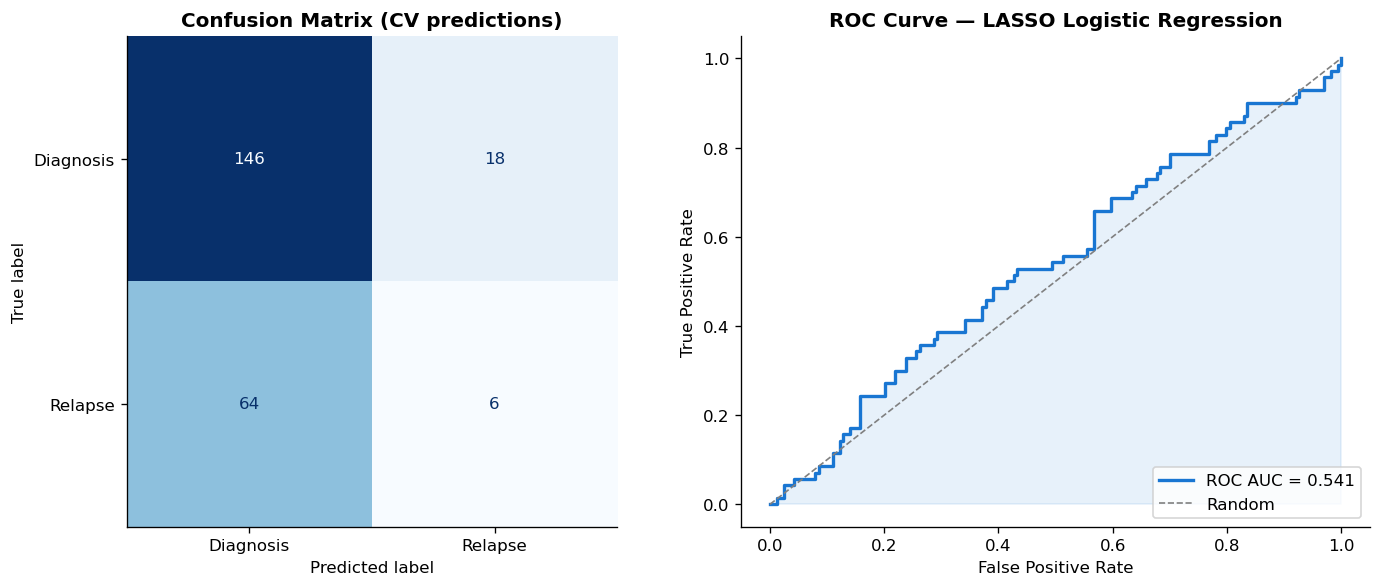

In [22]:
# Confusion matrix + ROC curve

fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
roc_auc_val = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(y, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Diagnosis', 'Relapse'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (CV predictions)', fontweight='bold')

# ROC curve
axes[1].plot(fpr, tpr, color='#1976D2', lw=2, label=f'ROC AUC = {roc_auc_val:.3f}')
axes[1].plot([0,1],[0,1], color='gray', lw=1, ls='--', label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#1976D2')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — LASSO Logistic Regression', fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [27]:
J = tpr - fpr
opt_thresh_idx = np.argmax(J)
opt_thresh = thresholds[opt_thresh_idx]

y_pred_opt = (y_pred_proba >= opt_thresh).astype(int)
print(f'Youden optimal threshold: {opt_thresh:.3f}')
print()
print('=== Classification Report at Optimal Threshold ===')
print(classification_report(y, y_pred_opt, target_names=['Diagnosis', 'Relapse']))

Youden optimal threshold: 0.304

=== Classification Report at Optimal Threshold ===
              precision    recall  f1-score   support

   Diagnosis       0.74      0.57      0.64       164
     Relapse       0.34      0.53      0.42        70

    accuracy                           0.56       234
   macro avg       0.54      0.55      0.53       234
weighted avg       0.62      0.56      0.57       234



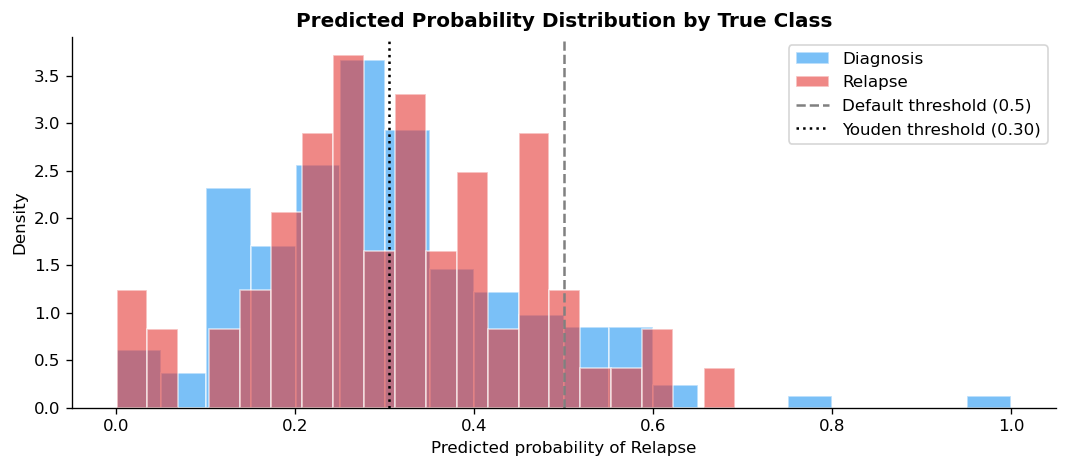

In [28]:
# Predicted probability distributions

fig, ax = plt.subplots(figsize=(9, 4))
for phase, label, color in [('Diagnosis', 0, '#2196F3'), ('Relapse', 1, '#E53935')]:
    ax.hist(y_pred_proba[y == label], bins=20, alpha=0.6,
            color=color, label=phase, density=True, edgecolor='white')
ax.axvline(0.5, color='gray', ls='--', lw=1.5, label='Default threshold (0.5)')
ax.axvline(opt_thresh, color='black', ls=':', lw=1.5, label=f'Youden threshold ({opt_thresh:.2f})')
ax.set_xlabel('Predicted probability of Relapse')
ax.set_ylabel('Density')
ax.set_title('Predicted Probability Distribution by True Class', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
# 8. Permutation Feature Importance

Permutation importance measures how much the AUC drops when each feature is randomly shuffled — a model-agnostic, robust complement to coefficient magnitude.

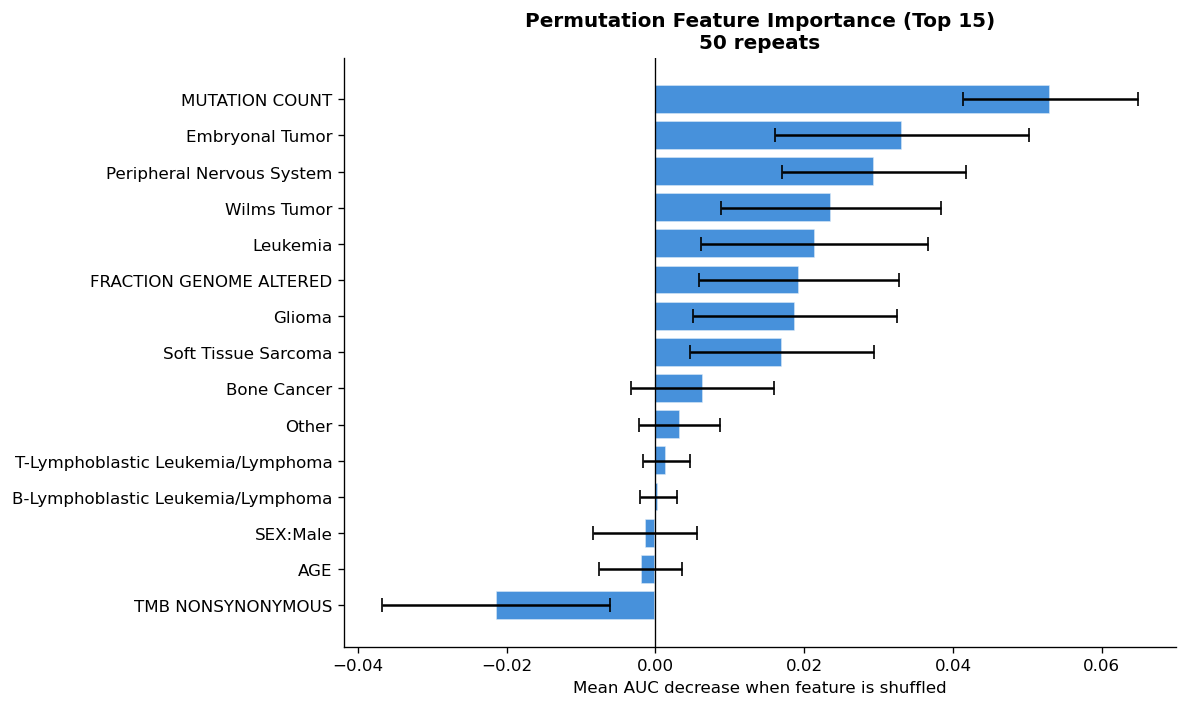

In [25]:
# Permutation importance

perm_imp = permutation_importance(
    lasso_model, X_scaled, y,
    scoring='roc_auc', n_repeats=50, random_state=SEED, n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': perm_imp.importances_mean,
    'std':        perm_imp.importances_std
}).sort_values('importance', ascending=True)

# Show top 15 by absolute importance
perm_top = perm_df.nlargest(15, 'importance').sort_values('importance')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(perm_top)), perm_top['importance'],
        xerr=perm_top['std'], color='#1976D2', alpha=0.8,
        edgecolor='white', capsize=4)
ax.set_yticks(range(len(perm_top)))
ax.set_yticklabels([f.replace('CT_','').replace('SEX_','SEX:').replace('_',' ')
                    for f in perm_top['feature']], fontsize=10)

ax.set_xlabel('Mean AUC decrease when feature is shuffled')
ax.set_title('Permutation Feature Importance (Top 15)\n50 repeats', fontweight='bold')
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

---
# 9. Summary & Interpretation

In [26]:
# Final summary table

final_coef_df = pd.DataFrame({
    'Feature': feature_names,
    'LASSO Coefficient': lasso_model.coef_[0],
    'Perm Importance (AUC drop)': perm_imp.importances_mean
})

final_coef_df = final_coef_df[final_coef_df['LASSO Coefficient'] != 0]
final_coef_df = final_coef_df.reindex(
    final_coef_df['LASSO Coefficient'].abs().sort_values(ascending=False).index
)
final_coef_df['Direction'] = final_coef_df['LASSO Coefficient'].apply(
    lambda x: '↑ Relapse' if x > 0 else '↓ Relapse'
)
final_coef_df.reset_index(drop=True, inplace=True)
final_coef_df.index += 1  # 1-indexed

print('=== Selected Features at Optimal LASSO (ranked by |coefficient|) ===')
print(final_coef_df[['Feature','LASSO Coefficient','Direction','Perm Importance (AUC drop)']].to_string())

print(f'\n=== Model Summary ===')
print(f'Total features             : {len(feature_names)}')
print(f'Selected by LASSO          : {nonzero_mask.sum()}')
print(f'Sparsity                   : {(~nonzero_mask).mean()*100:.1f}% zeroed out')
print(f'CV ROC-AUC                 : {results["LASSO (L1)"]["AUC mean"]:.3f} ± {results["LASSO (L1)"]["AUC std"]:.3f}')
print(f'CV Accuracy                : {results["LASSO (L1)"]["Acc mean"]:.3f} ± {results["LASSO (L1)"]["Acc std"]:.3f}')

=== Selected Features at Optimal LASSO (ranked by |coefficient|) ===
                                 Feature  LASSO Coefficient  Direction  Perm Importance (AUC drop)
1                      TMB_NONSYNONYMOUS          -1.265938  ↓ Relapse                   -0.021427
2                         MUTATION_COUNT           1.217498  ↑ Relapse                    0.053103
3                         CT_Wilms Tumor          -0.326975  ↓ Relapse                    0.023627
4                            CT_Leukemia          -0.281179  ↓ Relapse                    0.021408
5                     CT_Embryonal Tumor          -0.268471  ↓ Relapse                    0.033211
6                              CT_Glioma           0.239432  ↑ Relapse                    0.018763
7           CT_Peripheral Nervous System           0.229120  ↑ Relapse                    0.029411
8                FRACTION_GENOME_ALTERED          -0.209671  ↓ Relapse                    0.019303
9                 CT_Soft Tissue Sarcoma

## Conclusions

### Model Performance:

* Every model variant regardless of LASSO, Elastic Net, Ridge all converged on essentially the same performance. The CV ROC-AUC ≈ 0.544 while the accuracy ≈ 65%. The 65% accuracy is largely explained by the class imbalance of 164 Diagnosis vs. 70 Relapse.


### Sparsity Findings:

* The optimal regularization strength was C = 79 so λ = 0.013. This is a very weak penalty term. This means LASSO kept all 15 features and nothing was zeroed out. The data doesn't support a sparse subset and there's no dominant sparse subset driving Diagnosis vs. Relapse in this feature space.

Overall, we found that this clinical file alone is insufficient for meaningful prediction of disease phrase. The feature space is too thin with only 4 genomic variables.